In [1]:
import sys 
sys.path.append('..')
sys.path.append('../src')
from waypoint_dataset import WaypointDataset
from torch.utils.data import DataLoader, Dataset
from model_v1 import ModelV1
import torchvision.transforms as transforms
import numpy as np
from model_context import ModelContext

Using device: mps


In [2]:
dataset_str = 'outside_hallway'

In [3]:
import torch 
import torch.nn as nn
from sklearn.model_selection import train_test_split


model_context = ModelContext(levels=[16, 32, 64], waypoint_num=4, hidden_dim=64)


transform = transforms.Compose([
    transforms.Resize((model_context.height, model_context.width)),
    transforms.ToTensor(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
    transforms.Normalize(mean=model_context.mean, std=model_context.std)
])

dataset = WaypointDataset(data_folder=dataset_str, frame_skips=2, model_context=model_context, transform=transform)
batch_size = 32
train_split = 0.90

train_idx, val_idx = train_test_split(list(range(len(dataset))), train_size=train_split, random_state=42)

  # Create data loaders
train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
val_sampler = torch.utils.data.SubsetRandomSampler(val_idx)

train_loader = DataLoader(dataset, batch_size=batch_size,
                            sampler=train_sampler, num_workers=0)
val_loader = DataLoader(dataset, batch_size=batch_size, 
                        sampler=val_sampler, num_workers=0)

In [4]:
model = ModelV1(model_context=model_context).to(model_context.device)
## Setup optimizer and loss function
train_iters = 40
learning_rate = 1e-3
warmup_steps = 2000

def warmup_lr(step):
    return min(step, warmup_steps) / warmup_steps

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_lr)
criterion = nn.MSELoss()

dummy_input = torch.randn(2, 3, model_context.height, model_context.width).to(model_context.device)
with torch.no_grad():
    dummy_output = model(dummy_input)
print("Dummy output shape:", dummy_output.shape)



Dummy output shape: torch.Size([2, 4, 2])


In [5]:
from train import train_model, view_evaluation_sample, view_val_train_loss

In [6]:
avg_losses, avg_val_losses = train_model(model = model,
                                         train_loader = train_loader,
                                         val_loader = val_loader,
                                         criterion = criterion,
                                         optimizer = optimizer,
                                         scheduler = scheduler,
                                         train_iters = train_iters,
                                         save_model_path = dataset_str,
                                         model_context = model_context, 
                                         custom_loss = True)

Epoch [1/40], Loss: 0.7987
Validation Loss: 0.2053
Saved best model with validation loss: 0.2053
Epoch [2/40], Loss: 0.4309
Validation Loss: 0.1769
Saved best model with validation loss: 0.1769
Epoch [3/40], Loss: 0.3795
Validation Loss: 0.1719
Saved best model with validation loss: 0.1719
Epoch [4/40], Loss: 0.3190
Validation Loss: 0.1320
Saved best model with validation loss: 0.1320
Epoch [5/40], Loss: 0.2643
Validation Loss: 0.1032
Saved best model with validation loss: 0.1032
Epoch [6/40], Loss: 0.2442
Validation Loss: 0.1307
Epoch [7/40], Loss: 0.2384
Validation Loss: 0.1140
Epoch [8/40], Loss: 0.2022
Validation Loss: 0.0956
Saved best model with validation loss: 0.0956
Epoch [9/40], Loss: 0.2042
Validation Loss: 0.0891
Saved best model with validation loss: 0.0891
Epoch [10/40], Loss: 0.1905
Validation Loss: 0.1158
Epoch [11/40], Loss: 0.1794
Validation Loss: 0.0785
Saved best model with validation loss: 0.0785
Epoch [12/40], Loss: 0.1664
Validation Loss: 0.1089
Epoch [13/40], Lo

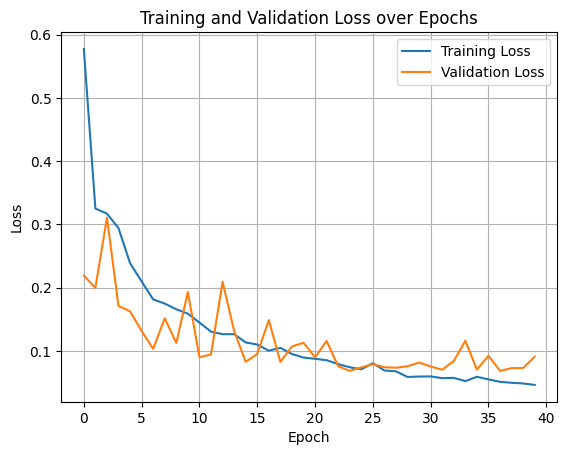

In [8]:
view_val_train_loss(avg_losses, avg_val_losses)

In [7]:

best_model = ModelV1(model_context=model_context).to(model_context.device)
best_model.load_state_dict(torch.load(f'../models/{dataset_str}/best_model.pth'))

<All keys matched successfully>

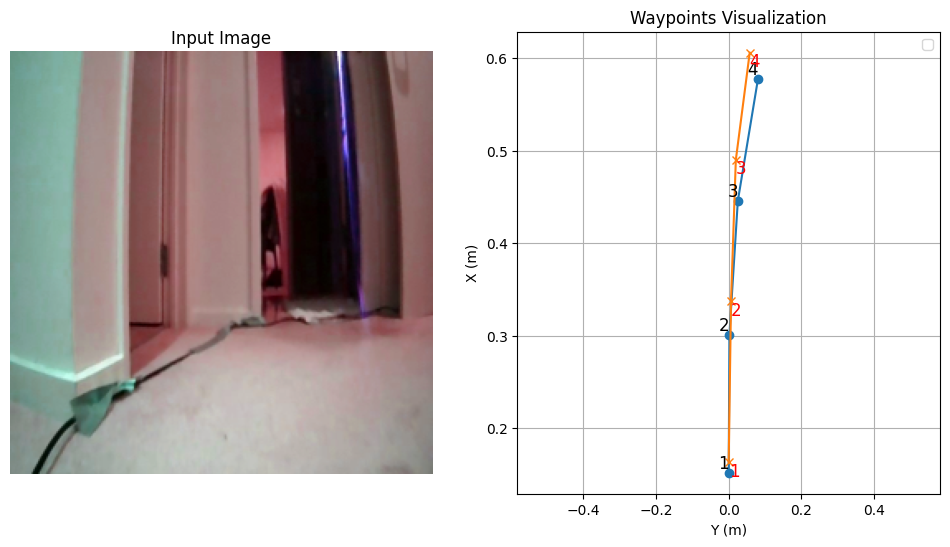

2229


In [15]:
sampple_idx = np.random.randint(0, len(dataset))
o_t, waypoints = dataset[sampple_idx]
view_evaluation_sample(o_t, waypoints, best_model, model_context)
print(sampple_idx)

In [16]:
from export_model import export_model_to_onnx

export_model_to_onnx(best_model, dataset_str, model_name="outside_hallway", model_context=model_context)

ONNX model is valid.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from ipywidgets import interactive

class Position():
    def __init__(self, x, y, yaw):
        self.x = x
        self.y = y
        self.yaw = yaw

class Observation():
    def __init__(self, image, ref_position: Position, waypoints):
        self.image = image
        self.ref_position = ref_position
        self.waypoint_in_odom_frame = waypoints

class ReplayModelRollout:
    def __init__(self, 
                 data_dir, 
                 model_context: ModelContext):
        self.data_dir = data_dir
        self.model_context = model_context
        self.observations = []
        self.load_data()

    def load_data(self):
        data = pd.read_csv(f'{self.data_dir}/debug_data.csv')
        for index, row in data.iterrows():
            waypoints = []

            ref_position = Position(row['ref_x'], row['ref_y'], row['ref_yaw'])
            for i in range(self.model_context.waypoint_num):
                wp_x = row[f'wp_{i}_x']
                wp_y = row[f'wp_{i}_y']
                waypoints.append(Position(wp_x, wp_y, 0.0))

            # This is done because how we normalise in TensorRT inference engine
            # specifically using the deepstream nvpreprocess plugin with the pixel normalisation
            mean_vals = list(self.model_context.mean)
            for i in range(len(mean_vals)):
                mean_vals[i] = mean_vals[i] * self.model_context.std[i]
            

            array = np.fromfile(f'{self.data_dir}/input_tensor_{index}.bin', dtype=self.model_context.data_type_np)
            tensor = array.reshape(1, self.model_context.channels, self.model_context.height, self.model_context.width)
            mean_np_array = np.array(mean_vals).reshape(1, self.model_context.channels, 1, 1)
            std_np_array = np.array(self.model_context.std).reshape(1, self.model_context.channels, 1, 1)
            x = (tensor[0] * std_np_array) + mean_np_array
            x = x.squeeze(0)
            x = x.clip(0, 1)

            observation = Observation(image=x, ref_position=ref_position, waypoints=waypoints)
            self.observations.append(observation)

    def see_observations_with_slider(self):
        max_y = 0.5
        max_x = 1.0
        def show_frame(index):
            obs = self.observations[index]
            img = obs.image.transpose(1, 2, 0)
            waypoints = obs.waypoint_in_odom_frame

            wp_xs = [wp.x for wp in waypoints]
            wp_ys = [-wp.y for wp in waypoints]

            fig, axs = plt.subplots(1, 2, figsize=(12, 6))

            # Left: image
            axs[0].imshow(img)
            axs[0].set_title(f'Observation {index}')
            axs[0].axis('off')

            # Right: waypoints
            axs[1].plot(wp_ys, wp_xs, 'ro-')
            axs[1].set_title('Waypoints in Odom Frame')
            axs[1].set_xlabel('Y (m)')
            axs[1].set_ylabel('X (m)')
            axs[1].set_xlim([-max_y, max_y])
            axs[1].set_ylim([0, max_x])
            plt.show()

        interactive_plot = interactive(show_frame, index=(0, len(self.observations) - 1))
        output = interactive_plot.children[-1]
        output.layout.height = '600px'
        display(interactive_plot)


    def see_observation(self, index):
        obs = self.observations[index]
        img = obs.image.transpose(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)

        waypoints = obs.waypoint_in_odom_frame

        fig, axs = plt.subplots(1, 2, figsize=(12, 6))

        wp_xs = [wp.x for wp in waypoints]
        wp_ys = [-wp.y for wp in waypoints]
        axs[1].plot(wp_ys, wp_xs, 'ro-', label='Waypoints')
        axs[1].set_title('Waypoints in Odom Frame')

        max_y = max(abs(max(wp_ys)), abs(min(wp_ys))) + .5
        axs[1].set_xlim([-max_y, max_y])

        axs[1].set_xlabel('Y (m)')
        axs[1].set_ylabel('X (m)')
        axs[1].legend()

        axs[0].imshow(img)
        axs[0].set_title('Observation Image')
        plt.show()

    def plot_all_waypoints(self):
        fig, ax = plt.subplots(figsize=(8, 8))

        max_y = float('-inf')

        for idx, obs in enumerate(self.observations):
            if (idx < 6 or idx > 25):
                continue    
            waypoints = list(obs.waypoint_in_odom_frame)
            transformed_waypoints = [self.base_to_world(obs.ref_position, wp.x, wp.y) for wp in waypoints]
            wp_xs = [wp[0] for wp in transformed_waypoints]
            wp_ys = [-wp[1] for wp in transformed_waypoints]
            ax.plot(wp_ys, wp_xs, 'ro-')
            max_y = max(max_y, max(abs(min(wp_ys)), abs(max(wp_ys))))

        max_y += 0.5    
        ax.set_xlim([-max_y, max_y])
        ax.set_xlabel('Y (m)')
        ax.set_ylabel('X (m)')        

        ax.set_title('All Waypoints in Odom Frame')
        plt.show()

    def base_to_world(self, position: Position, base_x, base_y):
        import math
        cos_yaw = math.cos(position.yaw)
        sin_yaw = math.sin(position.yaw)

        world_x = position.x + (base_x * cos_yaw - base_y * sin_yaw)
        world_y = position.y + (base_x * sin_yaw + base_y * cos_yaw)

        return (world_x, world_y)


base_arr = '/Users/tom/Development/carbot_ai_model/model_rollouts'
rollout = ReplayModelRollout(data_dir=f'{base_arr}/1762995347', model_context=model_context)
rollout.see_observations_with_slider()

interactive(children=(IntSlider(value=37, description='index', max=74), Output(layout=Layout(height='600px')))…